In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [3]:
import pandas as pd
import glob
import os

# Path to your Excel files
file_paths = glob.glob('data_leaks/benchmark/train_guan/*.xlsx')

# List to store individual DataFrames
dfs = []

# Loop through each file
for file_path in file_paths:
    df = pd.read_excel(file_path)
    # Add filename (without extension) as 'id'
    df['id'] = os.path.splitext(os.path.basename(file_path))[0]
    dfs.append(df)

# Concatenate all DataFrames into one
combined_df = pd.concat(dfs, ignore_index=True)

# Show result
combined_df.head()

,time,station_id,total,free,busy,id
0,2021-12-10 00:00:00,26323,24,4,20,26323
1,2021-12-10 00:05:00,26323,24,4,20,26323
2,2021-12-10 00:10:00,26323,24,4,20,26323
3,2021-12-10 00:15:00,26323,24,4,20,26323
4,2021-12-10 00:20:00,26323,24,4,20,26323


In [4]:
combined_df.shape

(250560, 6)

C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
C:\Users\arthu\AppData\Local\Temp\ipykernel_12800\3765291205.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivoted = pivoted.fillna(method='ffill').fillna(method='bfill')  # handle missing values
C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


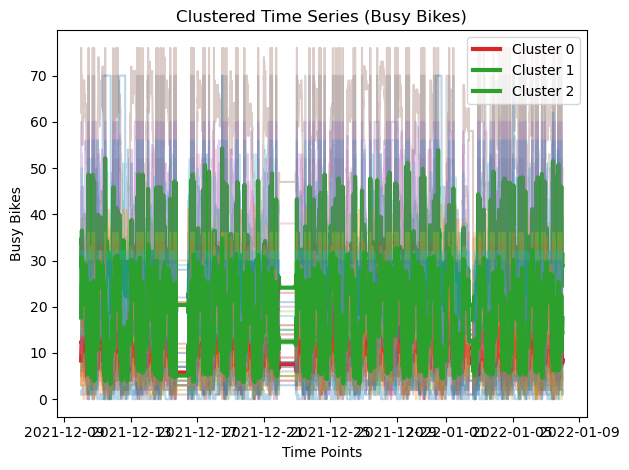

In [6]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



# Pivot the time series: one row per station (id), one column per timestamp
pivoted = combined_df.pivot(index='time', columns='id', values='busy')  # or 'free'/'total'
pivoted = pivoted.fillna(method='ffill').fillna(method='bfill')  # handle missing values
pivoted = pivoted.T  # now each row is a time serie

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivoted)

n_clusters = 3  # pick based on your data
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the pivoted data
pivoted['cluster'] = labels

import matplotlib.pyplot as plt

# Plot cluster centroids
for cluster_id in range(n_clusters):
    series = pivoted[pivoted['cluster'] == cluster_id].drop('cluster', axis=1)
    plt.plot(series.T, alpha=0.3)  # all series in cluster
    plt.plot(series.mean(axis=0), label=f'Cluster {cluster_id}', linewidth=3)

plt.title('Clustered Time Series (Busy Bikes)')
plt.xlabel('Time Points')
plt.ylabel('Busy Bikes')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Reshape for tslearn: (n_samples, n_timestamps, 1)
X_ts = pivoted.drop('cluster', axis=1).values[:, :, None]
X_ts = TimeSeriesScalerMeanVariance().fit_transform(X_ts)

model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=0)
labels = model.fit_predict(X_ts)

MemoryError: Unable to allocate 532. MiB for an array with shape (8352, 8352) and data type float64

C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
C:\Users\arthu\AppData\Local\Temp\ipykernel_972\1252445231.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivoted = pivoted.fillna(method='ffill').fillna(method='bfill')


Euclidean k-means
71.931 --> 43.736 --> 43.082 --> 43.082 --> 
DBA k-means (DTW)
Init 1


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


34.297 --> 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


...

23.923 --> 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


23.923 --> 


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


Soft-DTW k-means
1329.394 --> 641.708 --> 601.065 --> 601.122 --> 601.108 --> 601.108 --> 601.107 --> 601.117 --> 601.104 --> 601.104 --> 601.101 --> 601.100 --> 601.099 --> 601.098 --> 601.097 --> 601.097 --> 601.097 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 


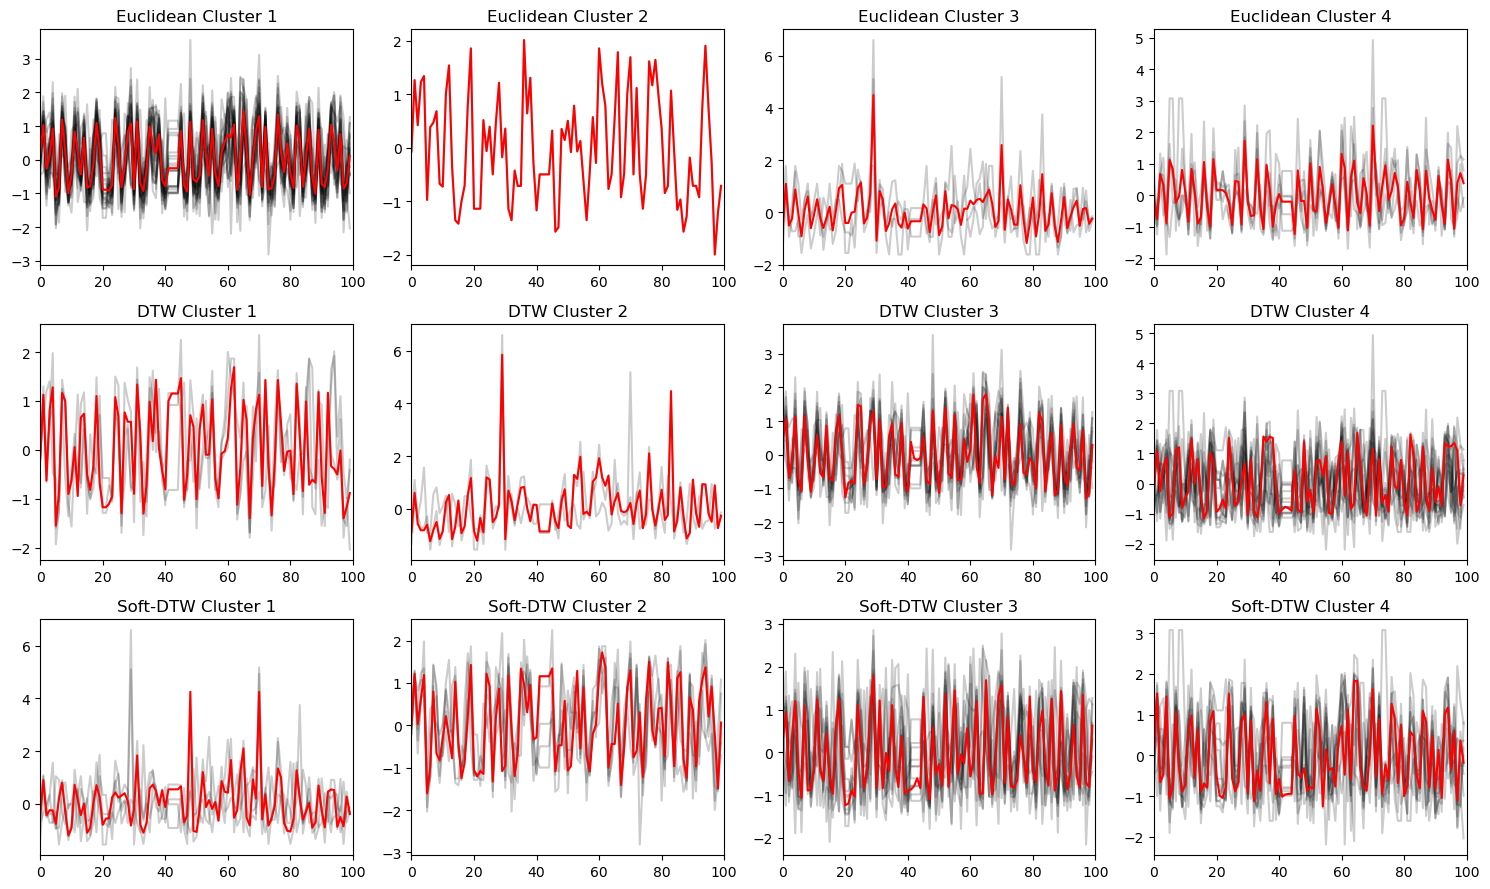

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler

# -----------------------------
# Step 1: Load your data
# -----------------------------
file_paths = glob.glob('data_leaks/benchmark/train_guan/*.xlsx')
dfs = []

for path in file_paths:
    df = pd.read_excel(path)
    df['id'] = os.path.splitext(os.path.basename(path))[0]
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df['time'] = pd.to_datetime(combined_df['time'])

# -----------------------------
# Step 2: Pivot into (n_samples, n_timestamps)
# -----------------------------
# Choose 'busy' as the metric to cluster
pivoted = combined_df.pivot(index='time', columns='id', values='busy')
pivoted = pivoted.fillna(method='ffill').fillna(method='bfill')
pivoted = pivoted.T  # Each row is one time series

# -----------------------------
# Step 3: Convert to 3D array (n_samples, n_timestamps, 1)
# -----------------------------
X = pivoted.values[:, :, np.newaxis]  # Add dimension for tslearn

# Rescale
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X)

# Optional: Resample to fixed length (e.g., 40 timestamps)
X_resampled = TimeSeriesResampler(sz=100).fit_transform(X_scaled)
sz = X_resampled.shape[1]

# -----------------------------
# Step 4: Clustering
# -----------------------------
seed = 0
n_clusters = 4

print("Euclidean k-means")
km = TimeSeriesKMeans(n_clusters=n_clusters, verbose=True, random_state=seed)
y_pred_euc = km.fit_predict(X_resampled)

print("DBA k-means (DTW)")
dba_km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", n_init=2,
                          verbose=True, max_iter_barycenter=10, random_state=seed)
y_pred_dba = dba_km.fit_predict(X_resampled)

print("Soft-DTW k-means")
sdtw_km = TimeSeriesKMeans(n_clusters=n_clusters, metric="softdtw",
                           metric_params={"gamma": .01}, verbose=True, random_state=seed)
y_pred_sdtw = sdtw_km.fit_predict(X_resampled)

# -----------------------------
# Step 5: Plot results
# -----------------------------
plt.figure(figsize=(15, 9))

for cluster_id in range(n_clusters):
    # Euclidean
    plt.subplot(3, n_clusters, cluster_id + 1)
    for ts in X_resampled[y_pred_euc == cluster_id]:
        plt.plot(ts.ravel(), "k-", alpha=0.2)
    plt.plot(km.cluster_centers_[cluster_id].ravel(), "r-")
    plt.title(f"Euclidean Cluster {cluster_id + 1}")
    plt.xlim(0, sz)

    # DBA (DTW)
    plt.subplot(3, n_clusters, n_clusters + cluster_id + 1)
    for ts in X_resampled[y_pred_dba == cluster_id]:
        plt.plot(ts.ravel(), "k-", alpha=0.2)
    plt.plot(dba_km.cluster_centers_[cluster_id].ravel(), "r-")
    plt.title(f"DTW Cluster {cluster_id + 1}")
    plt.xlim(0, sz)

    # Soft-DTW
    plt.subplot(3, n_clusters, 2 * n_clusters + cluster_id + 1)
    for ts in X_resampled[y_pred_sdtw == cluster_id]:
        plt.plot(ts.ravel(), "k-", alpha=0.2)
    plt.plot(sdtw_km.cluster_centers_[cluster_id].ravel(), "r-")
    plt.title(f"Soft-DTW Cluster {cluster_id + 1}")
    plt.xlim(0, sz)

plt.tight_layout()
plt.show()

In [17]:
df = combined_df.copy()
df['avaliable'] = df['free'] / df['total']
df['timestep'] = ((df['time'] - df['time'].min()).dt.total_seconds() // 300).astype(int)
df.head()

,time,station_id,total,free,busy,id,avaliable,timestep
0,2021-12-10 00:00:00,26323,24,4,20,26323,0.166667,0
1,2021-12-10 00:05:00,26323,24,4,20,26323,0.166667,1
2,2021-12-10 00:10:00,26323,24,4,20,26323,0.166667,2
3,2021-12-10 00:15:00,26323,24,4,20,26323,0.166667,3
4,2021-12-10 00:20:00,26323,24,4,20,26323,0.166667,4


In [35]:
qwe = df[df['timestep'] <= 5][['timestep', 'avaliable', 'station_id']]
t1 = qwe[(qwe['avaliable'] >= .80) & (qwe['avaliable'] < 1)]
t1.station_id.unique()

array([43382, 43823, 85295, 87579], dtype=int64)

In [37]:
t2 = qwe[(qwe['avaliable'] >= .15) & (qwe['avaliable'] < 0.40)]
t2.station_id.unique()

array([26323, 26898, 36284, 37402, 38764, 40575, 42148, 42149, 42945,
       43976, 43989, 72022, 72122, 80458, 80543, 86229, 87588, 88842],
      dtype=int64)

In [39]:
t3 = qwe[(qwe['avaliable'] >= .50) & (qwe['avaliable'] < 0.80)]
t3.station_id.unique()

array([26898, 36284, 38764, 40574, 42149, 42760, 43382, 43821, 43823,
       43989, 72122, 80134, 80458, 80459, 80543, 85271, 87581, 87587,
       87588], dtype=int64)

<Axes: xlabel='timestep', ylabel='avaliable'>

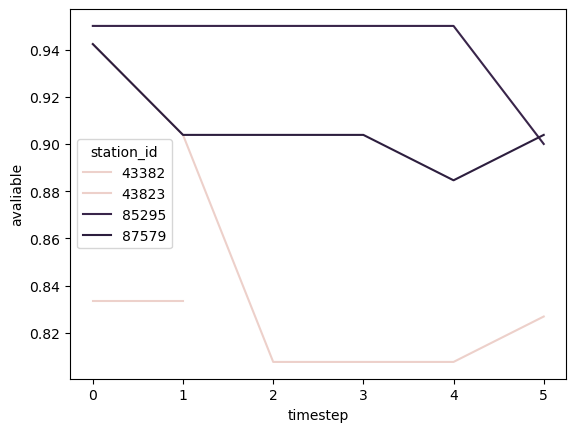

In [43]:
import seaborn as sns

sns.lineplot(data = t1,
            x = 'timestep',
            y = 'avaliable',
            hue = 'station_id')

In [16]:
import pandas as pd
import os
import glob

# Step 1: Load all Excel files
file_paths = glob.glob('data_leaks/benchmark/test_guan/*.xlsx')
station_dfs = []

for path in file_paths:
    df = pd.read_excel(path)

    # Convert time to datetime
    df['timestamp'] = pd.to_datetime(df['time'])

    # Get station_id (assume all rows in file have same value)
    station_id = df['station_id'].iloc[0]

    # Create a new column: available = free / total
    df[f'{station_id}'] = df['free'] / df['total']

    # Keep only relevant columns
    df = df[['timestamp', f'{station_id}']]

    # Set time as index
    # df = df.set_index('time')

    station_dfs.append(df)

# Step 2: Combine all into one DataFrame (time index, station_id columns)
df_test = pd.concat(station_dfs, axis=1)

# Step 3: (Optional) Create timestep column based on 5-min intervals
df_test = df_test.sort_index()
# df_test['timestep'] = ((df_test.index - df_test.index.min()).total_seconds() // 300).astype(int)
df_test = df_test.loc[:, ~df_test.columns.duplicated()]

# Done!
df_test.head()

,timestamp,89086,89449,89450,89451,89453
0,2021-12-10 00:00:00,0.60,0.7,0.869565,0.551724,0.550
1,2021-12-10 00:05:00,0.48,0.8,0.804348,0.482759,0.550
2,2021-12-10 00:10:00,0.44,0.8,0.804348,0.517241,0.525
3,2021-12-10 00:15:00,0.40,0.7,0.739130,0.448276,0.525
4,2021-12-10 00:20:00,0.40,0.6,0.717391,0.413793,0.500


In [8]:
for client in df_test.columns:
    print(client)

89086
89449
89450
89451
89453
timestep


In [13]:
df_test[[client]]

,timestep
time,
2021-12-10 00:00:00,0
2021-12-10 00:05:00,1
2021-12-10 00:10:00,2
2021-12-10 00:15:00,3
2021-12-10 00:20:00,4
...,...
2022-01-07 23:35:00,8347
2022-01-07 23:40:00,8348
2022-01-07 23:45:00,8349


<Axes: xlabel='time', ylabel='avaliable'>

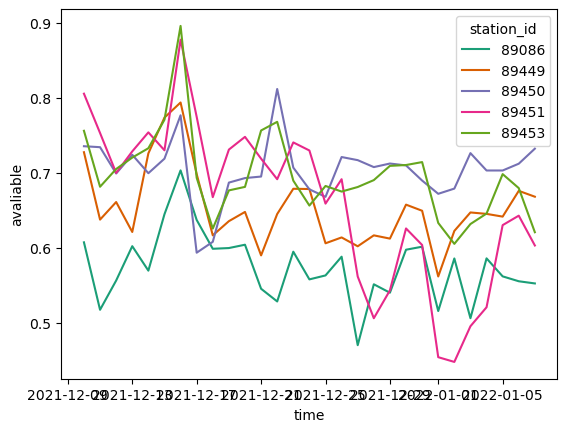

In [125]:
df_plot = df_test.groupby('station_id').resample('24h')['avaliable'].mean().reset_index()
# df_plot = df_plot[df_plot['timestep'] > 7000]
sns.lineplot(data = df_plot,#[df_plot['station_id'].isin([89450, 89453, 89449])],
            x = 'time',
            y = 'avaliable',
            hue = 'station_id',
            palette = 'Dark2',
            )

In [155]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from argparse import Namespace
from typing import Dict

from backbone.AER import AER
from utils.build_aer_model import build_model_from_json_file

from datasets.utils.federated_dataset import FederatedDataset
from simulation.utils.configs import get_domain_sensor_map

from utils.timeseries_preprocessing import time_segments_aggregate, rolling_window_sequences, slice_array_by_dims

class BenchmarkDatasetBuilder:
    def __init__(self, id_network: str, id_exp: str, root_dir: str = "data_leaks"):
        self.data = None
        self.id_network = id_network
        self.id_exp = id_exp
        self.root_dir = root_dir
        
    def load_data(self):
        # Step 1: Load all Excel files
        file_paths = glob.glob('data_leaks/benchmark/test_guan/*.xlsx')
        station_dfs = []
        
        for path in file_paths:
            df = pd.read_excel(path)
        
            # Convert time to datetime
            df['time'] = pd.to_datetime(df['time'])
        
            # Get station_id (assume all rows in file have same value)
            station_id = df['station_id'].iloc[0]
        
            # Create a new column: available = free / total
            df[f'{station_id}'] = df['free'] / df['total']
        
            # Keep only relevant columns
            df = df[['time', f'{station_id}']]
        
            # Set time as index
            df = df.set_index('time')
        
            station_dfs.append(df)
        
        # Step 2: Combine all into one DataFrame (time index, station_id columns)
        df_test = pd.concat(station_dfs, axis=1)
        
        # Step 3: (Optional) Create timestep column based on 5-min intervals
        df_test = df_test.sort_index()

        # Done!
        self.data = df_test


    def build_and_save(self, save_dir="datasets/benchmark"):
        if self.data is None:
            raise ValueError("Data not loaded. Call load_data() first.")

        client_map = ['A', 'B', 'C', 'D', 'E']
        for i, client in enumerate(self.data.columns):

            # Ensure output directory exists
            client_save_dir = os.path.join(save_dir, self.id_network, self.id_exp)
            os.makedirs(client_save_dir, exist_ok=True)

            # Save to CSV
            file_name = f"Client{client_map[i]}_{scenario}.csv"
            self.data[i].to_csv(os.path.join(client_save_dir, file_name), index=False)

    def get_data(self):
        return self.data
    
    def get_labels(self):
            return self.data


class FedBench(FederatedDataset):
    NAME = 'benchmark'
    SETTING = 'domain_skew'

    def __init__(self, args):
        super().__init__(args)
        self.scenario = None
        self.leaks_data = {}
        self.leaks_labels = {}
        self.scaler = None

        self.CLIENTS_DICT = args.domains
        self.DOMAINS_LIST = list(self.CLIENTS_DICT.keys())
        self.EXP_ID = [args.experiment_id for _ in self.DOMAINS_LIST] if isinstance(args.experiment_id, str) else args.experiment_id
        self.MAP_CLIENTS = [name for name, count in self.CLIENTS_DICT.items() for _ in range(count)]
        self.EXPERIMENT_IDS = {D: E for D, E in zip(self.DOMAINS_LIST, self.EXP_ID)}



    def get_data_loaders(self, selected_domain_list=[], scenario='Baseline'):

        using_list = self.DOMAINS_LIST if len(selected_domain_list) == 0 else selected_domain_list
        self.scenario = scenario

        # TODO não acho que lista com dominios seja o melhor para os dloaders
        # Load the raw data and save individual files for each domain/client/scenario
        for _, domain in enumerate(using_list):
            builder = BenchmarkDatasetBuilder(id_network=domain, id_exp=self.EXPERIMENT_IDS[domain])
            builder.load_data()
            builder.build_and_save()
            self.leaks_data[domain] = builder.get_data()  # for each domain holds a dict with clients/scenarios
            self.leaks_labels[domain] = builder.get_labels()

        traindls = []
        for domain in self.leaks_data.values():
            train_df = [
                self.preprocess_series(series=client_dict[self.scenario])
                for client_dict in domain.values()
                # if scenario in client_dict
            ]

            traindls.append(train_df)

        return [client for domain in traindls for client in domain]  # , testdls, federation#, train_dataset_list, test_dataset_list

    # @staticmethod
    def preprocess_series(self, series):
        """
        Full preprocessing pipeline: aggregation, normalization, rolling window.

        Args:
            series (pd.DataFrame): Raw time series with a 'timestamp' column.

        Returns:
            dict: A dictionary containing preprocessed data with keys:
                  'X', 'y', 'X_index', 'y_index', etc.
        """
        context = {}

        target_columns = [i for i in range(series.shape[1] - 1)]

        # Step 0: Aggregate time series
        aggregation_transform = self.get_aggregation_transform(interval=self.args.interval_agg)
        X_agg, idx_agg = aggregation_transform(series)
        context['X_raw'] = X_agg
        # context['index_raw'] = idx_agg

        # Step 1: Normalize
        normalize_transform = self.get_normalization_transform()
        X_norm = normalize_transform(X_agg)
        context['X'] = X_norm
        context['X_norm'] = X_norm
        context['index'] = idx_agg

        # Step 2: Rolling window
        rolling_transform = self.get_rolling_window_transform(window_size=self.args.window_size, step_size = self.args.step_size)
        X_seq, y_seq, X_idx, y_idx, win_idx, center_idx = rolling_transform(X_norm, idx_agg, target_columns)

        # Step 3: Slice targets from sequence
        y_seq = slice_array_by_dims(X_seq, target_index=target_columns, axis=2)

        # Store all results in context
        context['X'] = X_seq
        context['y'] = y_seq
        context['X_index'] = X_idx
        context['y_index'] = y_idx

        context['win_idx'] = win_idx
        context['center_idx'] = center_idx

        return context

    def get_labels(self):
        return self.leaks_labels

    # @staticmethod
    # TODO CORRIGIR PARAMETROS! ADICIRONAR CUSTOM DICT AQUI!
    def get_backbone(self, parti_num, names_list, n_series):
        nets_dict = {'aer': AER}
        nets_list = []
        if names_list is None:
            for j in range(parti_num):
                # TODO VERIFICAR CASOS EM QUE n_series É DIFERENTE!!
                net = initizalize_backbone(args=self.args)
                nets_list.append(net)
        else:
            for j in range(parti_num):
                net_name = names_list[j]
                nets_list.append(nets_dict[net_name]())
        return nets_list

    @staticmethod
    def get_aggregation_transform(interval=3 * 60 ** 2, method='mean', time_column='timestamp'):
        """
        Returns a transform function that aggregates time series data.
        """

        def transform(series):
            X, index = time_segments_aggregate(
                X=series,
                interval=interval,
                time_column=time_column,
                method=method
            )
            return X, index

        return transform

    # @staticmethod
    def get_normalization_transform(self):
        """
        Fits and applies MinMaxScaler, returns the scaled data.
        """

        def normalize(X):
            self.scaler = MinMaxScaler(feature_range=(-1, 1), copy=True)
            return self.scaler.fit_transform(X)

        return normalize

    def get_denormalization_transform(self):
        """
        Returns a function that reverses MinMaxScaler transform using the instance's scaler.
        """

        def denormalize(X):
            if not hasattr(self, 'scaler'):
                raise ValueError("Scaler not found. You must call the normalization function first.")
            return self.scaler.inverse_transform(X)

        return denormalize

    @staticmethod
    def get_rolling_window_transform(window_size=100, target_size=1, step_size=1, offset=0):
        """
        Returns a transform function that applies rolling windows.
        """

        def transform(X, index, target_columns):
            X_seq, y_seq, X_idx, y_idx, win_idx, center_idx = rolling_window_sequences(
                X=X,
                index=index,
                window_size=window_size,
                target_size=target_size,
                step_size=step_size,
                target_column=target_columns,
                offset=offset,
                drop=None,
                drop_windows=False,
                return_window_index=True,
                return_center_index=True
            )


            y_seq = slice_array_by_dims(X=X_seq, target_index=target_columns, axis=2)
            return X_seq, y_seq, X_idx, y_idx, win_idx, center_idx

        return transform

In [27]:
import warnings
from argparse import ArgumentParser

import pandas as pd

from datasets import Priv_NAMES as DATASET_NAMES
from datasets import get_private_dataset
from models import get_all_models
from models import get_model
from utils.Server import train
from utils.Toolbox_analysis import create_latent_df, process_latent_df

warnings.simplefilter(action='ignore', category=FutureWarning)


def parse_args():
    parser = ArgumentParser(description='You Only Need Me', allow_abbrev=False)
    parser.add_argument('--device_id', type=int, default=0, help='The Device Id for Experiment')
    parser.add_argument('--communication_epoch', type=int, default=3,
                        help='The Communication Epoch in Federated Learning')
    parser.add_argument('--local_epoch', type=int, default=3,
                        help='The Local Epoch for each Participant')

    parser.add_argument('--experiment_id', type=str,
                        default='Benchmark', help='Experiment identifier')
    parser.add_argument('--extra_coments', type=str,
                        default='TEST_BENCH', help='Aditional info')

    # Data parameter
    parser.add_argument('--dataset', type=str, default='benchmark', choices=DATASET_NAMES,
                        help='Which scenario to perform experiments on.')
    parser.add_argument('--domains', type=dict, default={'Benchmark': 5}, # TODO REFACTOR TYPE
                        help='Domains and respective number of participants.')

    ## Time series preprocessing
    parser.add_argument('--interval_agg', type=int, default=600,
                        help='Agregation interval (seconds) of time series')
    parser.add_argument('--window_size', type=int, default=5,
                        help='Rolling window length')
    parser.add_argument('--step_size', type=int, default=1,
                        help='Rolling window step size')

    # Model (AER) parameters
    parser.add_argument('--input_size', type=int, default=1,
                        help='Number of sensors')  # TODO adaptar
    parser.add_argument('--output_size', type=int, default=1,
                        help='Shape output - dense layer')
    parser.add_argument('--lstm_units', type=int, default=30,
                        help='Number of LSTM units (the latent space will have dimension 2 times bigger')

    # Participants info
    parser.add_argument('--parti_num', type=int, default=None,
                        help='The Number for Participants. If "None" will be setted as the sum of values described in --domain')
    parser.add_argument('--online_ratio', type=float, default=1,
                        help='The Ratio for Online Clients')

    # Federated parameters
    parser.add_argument('--model', type=str, default='fpl',
                        help='Federated Model name.', choices=get_all_models()) #fedavg
    parser.add_argument('--structure', type=str, default='homogeneity')
    parser.add_argument('--pri_aug', type=str, default='weak',  # weak strong
                        help='Augmentation for Private Data')
    parser.add_argument('--learning_decay', type=bool, default=False,
                        help='The Option for Learning Rate Decay')
    parser.add_argument('--averaging', type=str, default='weight',
                        help='The Option for averaging strategy')

    parser.add_argument('--infoNCET', type=float, default=0.02,
                        help='The InfoNCE temperature')
    parser.add_argument('--T', type=float, default=0.05,
                        help='The Knowledge distillation temperature')
    parser.add_argument('--weight', type=int, default=1,
                        help='The Weigth for the distillation loss')


        # Time variables
    parser.add_argument('--n_segments', type=int, default=12,
                        help='Number of urban growth simulation segments.')
    parser.add_argument('--epochs_lenght', type=int, default=6,
                        help='Number of epochs per simulation run.')
    parser.add_argument('--days_lenght', type=int, default=5,
                        help='Number of days in each epoch.')
    parser.add_argument('--n_intervals', type=int, default=24,
                        help='Number of time intervals per day.')

    # Hydraulic variables
    parser.add_argument('--unit', type=str, default='l/s',
                        help='Measurement unit for flow.')
    parser.add_argument('--leak_severity', type=float, default=0.15,
                        help='Leak severity multiplier.')

    args, unknown = parser.parse_known_args()

    if args.parti_num is None:
        args.parti_num = sum(args.domains.values())
    #
    # best = best_args[args.dataset][args.model]
    #
    # for key, value in best.items():
    #     setattr(args, key, value)
    #
    # if args.seed is not None:
    #     set_random_seed(args.seed)

    return args

In [28]:
args = parse_args()

priv_dataset = get_private_dataset(args)

In [29]:
backbones_list = priv_dataset.get_backbone(
                parti_num=args.parti_num,
                names_list=None,
                n_series=args.input_size
            )

model = get_model(backbones_list, args, priv_dataset)

train(model=model,
      private_dataset=priv_dataset,
      scenario='Baseline',
      args=args
      )

  0%|          | 0/3 [00:00<?, ?it/s]C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)

Local Participant 3 Loss = 0.243, MSE = 0.243, InfoNCE = 0.000:   0%|          | 0/3 [00:00<?, ?it/s]
Local Participant 3 Loss = 0.308, MSE = 0.308, InfoNCE = 0.000:   0%|          | 0/3 [00:01<?, ?it/s]
Local Participant 3 Loss = 0.226, MSE = 0.226, InfoNCE = 0.000:   0%|          | 0/3 [00:01<?, ?it/s]
Local Participant 3 Loss = 0.276, MSE = 0.276, InfoNCE = 0.000:   0%|          | 0/3 [00:01<?, ?it/s]
Local Participant 3 Loss = 0.231, MSE = 0.231, InfoNCE = 0.000:   0%|          | 0/3 [00:01<?, ?it/s]
Local Participant 3 Loss = 0.238, MSE = 0.238, InfoNCE = 0.000:   0%|          | 0/3 [00:01

AttributeError: 'Namespace' object has no attribute 'detect_anomalies'


Local Participant 1 Loss = 0.092, MSE = 0.092, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Participant 1 Loss = 0.079, MSE = 0.079, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Participant 1 Loss = 0.062, MSE = 0.062, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Participant 1 Loss = 0.084, MSE = 0.084, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Participant 1 Loss = 0.075, MSE = 0.075, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Participant 1 Loss = 0.084, MSE = 0.084, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Participant 1 Loss = 0.088, MSE = 0.088, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Participant 1 Loss = 0.089, MSE = 0.089, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Participant 1 Loss = 0.102, MSE = 0.102, InfoNCE = 0.000:  33%|███▎      | 1/3 [00:00<00:01,  1.72it/s]
Local Par

In [7]:
series = pd.read_csv('datasets/benchmark/Benchmark/Benchmark/ClientA_Baseline.csv')

series

,timestamp,89086
0,0,0.60
1,300,0.48
2,600,0.44
3,900,0.40
4,1200,0.40
...,...,...
8347,2504100,0.60
8348,2504400,0.48
8349,2504700,0.40
8350,2505000,0.44


In [21]:
priv_train_loaders = priv_dataset.get_data_loaders(scenario='Baseline')
priv_train_loaders[0].keys()

dict_keys(['X_raw', 'X', 'X_norm', 'index', 'y', 'X_index', 'y_index', 'win_idx', 'center_idx'])

In [10]:
priv_train_loaders[0].keys()

dict_keys(['X_raw', 'X', 'X_norm', 'index', 'y', 'X_index', 'y_index', 'win_idx', 'center_idx'])

In [24]:
from backbone.AER import get_majority_month_label

labels, mask = get_majority_month_label(windows_timestamps=priv_train_loaders[0]['win_idx'], threshold=0.75)
X_filtered = priv_train_loaders[0]['X'][mask].copy()

X_filtered

array([[[ 0.08]],

       [[-0.16]],

       [[-0.2 ]],

       ...,

       [[ 0.16]],

       [[ 0.24]],

       [[-0.12]]])

In [26]:
priv_train_loaders[0]['X']

array([[[ 0.08]],

       [[-0.16]],

       [[-0.2 ]],

       ...,

       [[ 0.16]],

       [[ 0.24]],

       [[-0.12]]])

In [24]:
import pandas as pd
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

# Sample setup
df['Available'] = df['free'].astype(float) / df['total'].astype(float)

# Ensure Available is a flat float array
df['Available'] = df['Available'].astype(float)

# Parameters
window_size = 12
windows = []

# Break the series into fixed-size windows
for i in range(0, len(df) - window_size + 1, window_size):
    window_data = df.iloc[i:i+window_size]['Available'].to_numpy().flatten()
    if window_data.ndim != 1:
        raise ValueError(f"Window {i} is not 1D: shape {window_data.shape}")
    windows.append((i, i+window_size, window_data))

In [ ]:
from fastdtw import fastdtw

# Define a scalar distance function
scalar_distance = lambda a, b: abs(a - b)

# DTW loop
min_distance = float('inf')
pair = (None, None)

for i in range(len(windows)):
    for j in range(i + 1, len(windows)):
        x = windows[i][2]
        y = windows[j][2]
        dist, _ = fastdtw(x, y, dist=scalar_distance)
        if dist < min_distance:
            min_distance = dist
            pair = (i, j)

print("Most similar pair of windows:", pair)


In [ ]:
import numpy as np

# Average of the two similar series
first_series_avg = (windows[first_pair_indices[0]][2] + windows[first_pair_indices[1]][2]) / 2

# Find another window (farther in time) that is similar
min_drift_distance = float('inf')
drift_candidate = None

for k in range(len(windows)):
    if k not in first_pair_indices:
        dist, _ = fastdtw(windows[k][2], first_series_avg, dist=euclidean)
        if dist < min_drift_distance:
            min_drift_distance = dist
            drift_candidate = k

print("Drift candidate window:", drift_candidate)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot the first similar pair
plt.plot(windows[first_pair_indices[0]][2], label='First similar series')
plt.plot(windows[first_pair_indices[1]][2], label='Second similar series')

# Plot the drift candidate
plt.plot(windows[drift_candidate][2], label='Drift candidate', linestyle='--')

plt.legend()
plt.title('Time Series Comparison')
plt.show()
